# Predicting Medical Insurance Charges — Initial Report & EDA

**Author:** Adil Sameer

**Capstone Assignment 20.1 — Initial Report and Exploratory Data Analysis**

---

## 1. Business Understanding — Research Question

> **To what extent can demographic and lifestyle factors — specifically age,
> BMI, smoking status, sex, number of dependents, and region — predict an
> individual's medical insurance charges?**

Medical insurance pricing often feels like a black box to the people paying for
it. The goal of this project is to make the cost drivers **transparent and
quantifiable**: to show, in plain dollar terms, how much a behaviour such as
smoking adds to a person's billed medical costs, and how weight, age, and other
factors contribute.

This is a **supervised regression** problem. In plain terms: "supervised" means
we already have the right answer (`charges`) for every person in the data and we
teach the model from those examples; "regression" means we're predicting a
**number** (a dollar amount) rather than a yes/no category.

### What this notebook delivers
1. **Data loading & quality checks** — missing values, duplicates, data types.
2. **Outlier analysis** — identify and interpret anomalies.
3. **Exploratory Data Analysis** — univariate and bivariate visual analysis for
   both categorical and continuous variables.
4. **Feature engineering** — encoding, transformations, and derived features.
5. **A baseline regression model** — Linear Regression, evaluated with MAE (and
   supporting metrics) to serve as the benchmark for the final capstone.


## Methodology: CRISP-DM

This project follows the **CRISP-DM** (Cross-Industry Standard Process for Data
Mining) framework. The six phases are iterative rather than strictly linear —
in practice the *Data Understanding* and *Data Preparation* phases interleave as
insights from EDA drive new cleaning and feature-engineering decisions. Each
numbered section below is tagged with the CRISP-DM phase it belongs to.

| CRISP-DM Phase | Where it appears in this notebook |
|---|---|
| **1. Business Understanding** | §1 — frame the research question and its value |
| **2. Data Understanding** | §3 first look · §5 outlier analysis · §6 EDA |
| **3. Data Preparation** | §4 data cleaning · §7 feature engineering |
| **4. Modeling** | §8 — baseline Linear Regression pipeline |
| **5. Evaluation** | §8.3–8.4 metrics & coefficients · §9 findings |
| **6. Deployment** | §9 *Next steps* |


## 2. Setup — Imports & Configuration

We import pandas/numpy for data handling, seaborn/matplotlib for visualization,
and scikit-learn for the baseline model. Aliases follow standard conventions
(`pd`, `np`, `sns`, `plt`).

In [1]:
# Ensure matplotlib has a writable cache directory (environment-specific)
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Display / plotting defaults for clean, readable output
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42  # reproducibility
print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Data Understanding — Load the Data & First Look

The **Medical Cost Personal Dataset**
([Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)) contains
1,338 records and 7 columns:

| Column | Type | Description |
|---|---|---|
| `age` | integer | Age of the primary beneficiary |
| `sex` | categorical | `female` / `male` |
| `bmi` | float | Body mass index (kg/m²) |
| `children` | integer | Number of dependents covered |
| `smoker` | categorical | `yes` / `no` |
| `region` | categorical | US region: NE, NW, SE, SW |
| `charges` | float | **Target** — individual medical costs billed |

In [2]:
# Load the dataset
df = pd.read_csv("data/insurance.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 1338 rows x 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,"16,884.92"
1,18,male,33.77,1,no,southeast,"1,725.55"
2,28,male,33.00,3,no,southeast,"4,449.46"
3,33,male,22.70,0,no,northwest,"21,984.47"
4,32,male,28.88,0,no,northwest,"3,866.86"


In [3]:
# Column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Summary statistics for numeric columns
df.describe()

,age,bmi,children,charges
count,"1,338.00","1,338.00","1,338.00","1,338.00"
mean,39.21,30.66,1.09,"13,270.42"
std,14.05,6.10,1.21,"12,110.01"
min,18.00,15.96,0.00,"1,121.87"
25%,27.00,26.30,0.00,"4,740.29"
50%,39.00,30.40,1.00,"9,382.03"
75%,51.00,34.69,2.00,"16,639.91"
max,64.00,53.13,5.00,"63,770.43"


In [5]:
# Summary of categorical columns
df.describe(include="object")

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


## 4. Data Preparation — Data Cleaning

We check for the three most common data-quality issues: **missing values**,
**duplicate rows**, and **incorrect data types**.

In [6]:
# 4.1 Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print("Missing values per column:")
missing_summary

Missing values per column:


,missing_count,missing_pct
age,0,0.00
sex,0,0.00
bmi,0,0.00
children,0,0.00
smoker,0,0.00
region,0,0.00
charges,0,0.00


In [7]:
# 4.2 Duplicate rows check
dup_count = df.duplicated().sum()
print(f"Number of fully duplicated rows: {dup_count}")
df[df.duplicated(keep=False)].sort_values(list(df.columns))

Number of fully duplicated rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,"1,639.56"
581,19,male,30.59,0,no,northwest,"1,639.56"


There is a single duplicated record. Because each row is meant to represent a
distinct beneficiary, an exact duplicate across all seven fields is most likely
a data-entry artifact rather than two genuinely identical people. We remove it
to avoid giving that observation double weight in the model.

In [8]:
# 4.3 Remove the duplicate row
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {rows_before - len(df)} duplicate row(s). New shape: {df.shape}")

Removed 1 duplicate row(s). New shape: (1337, 7)


In [9]:
# 4.4 Validate categorical values are within the expected domain
for col in ["sex", "smoker", "region"]:
    print(f"{col}: {sorted(df[col].unique())}")

sex: ['female', 'male']
smoker: ['no', 'yes']
region: ['northeast', 'northwest', 'southeast', 'southwest']


**Cleaning summary:** no missing values were found (the dataset is complete),
one exact duplicate row was removed, all categorical fields contain only valid
expected categories, and data types are already correct (integers, floats, and
objects as appropriate). The data is clean and ready for analysis.

## 5. Data Understanding — Outlier Analysis

We inspect the continuous (number) variables (`age`, `bmi`, `charges`) for
anomalies — values that sit far away from the rest. We plot a histogram of each
variable and draw the **IQR rule** fences on top as dashed lines. The IQR
(interquartile range) is just the middle 50% of the data; the common rule flags
any value beyond the fences — more than 1.5× the IQR below the 25th percentile
or above the 75th percentile — as a possible outlier. The goal here is to
*understand* these values, not to blindly delete them — in insurance data, a
very high charge is often a real, expensive patient rather than a mistake.

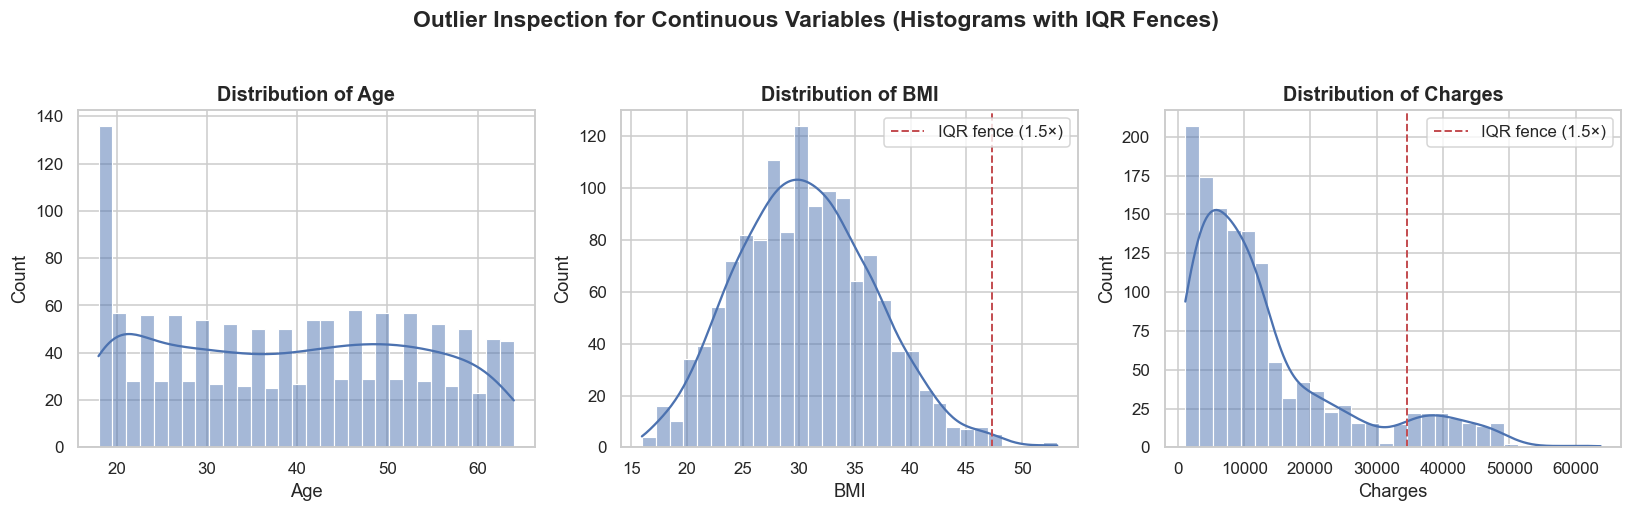

In [10]:
# Histograms with IQR outlier fences for the three continuous variables
num_cols = ["age", "bmi", "charges"]
labels = {"age": "Age", "bmi": "BMI", "charges": "Charges"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color="#4C72B0")
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    # Only draw a fence line if it actually falls within the data range
    drew_fence = False
    for fence in (lower, upper):
        if df[col].min() <= fence <= df[col].max():
            ax.axvline(fence, color="#C44E52", linestyle="--", linewidth=1.3,
                       label=None if drew_fence else "IQR fence (1.5×)")
            drew_fence = True
    ax.set_title(f"Distribution of {labels[col]}")
    ax.set_xlabel(labels[col])
    ax.set_ylabel("Count")
    if drew_fence:
        ax.legend()
fig.suptitle("Outlier Inspection for Continuous Variables (Histograms with IQR Fences)", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

In [11]:
# Quantify outliers using the IQR rule
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

outlier_report = []
for col in num_cols:
    count, lower, upper = iqr_outliers(df[col])
    outlier_report.append({
        "feature": col,
        "outlier_count": count,
        "outlier_pct": round(count / len(df) * 100, 2),
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
    })
pd.DataFrame(outlier_report)

,feature,outlier_count,outlier_pct,lower_bound,upper_bound
0,age,0,0.00,-9.00,87.00
1,bmi,9,0.67,13.67,47.32
2,charges,139,10.40,"-13,120.72","34,524.78"


**Interpretation of outliers**

- **`age`** has no statistical outliers — it spans a normal 18–64 adult range.
- **`bmi`** has a small number of high-BMI outliers. These are medically
  plausible (severe obesity) and are retained.
- **`charges`** shows the most "outliers", but this is expected and meaningful:
  the target is **right-skewed** and the high tail is largely driven by smokers
  and high-BMI individuals. These are *legitimate* high-cost patients, not data
  errors, so we **keep them**. Rather than dropping them, we prepare a
  log-transformed version of the target during feature engineering that can be
  used to reduce the skew's impact in later modeling.

We therefore do **not** remove any outlier rows — doing so would discard exactly
the high-cost cases the business question cares most about.

## 6. Data Understanding — Exploratory Data Analysis

### 6.1 Univariate — Distribution of the Target (`charges`)

Understanding the target's distribution guides both modeling and the choice of
error metric.

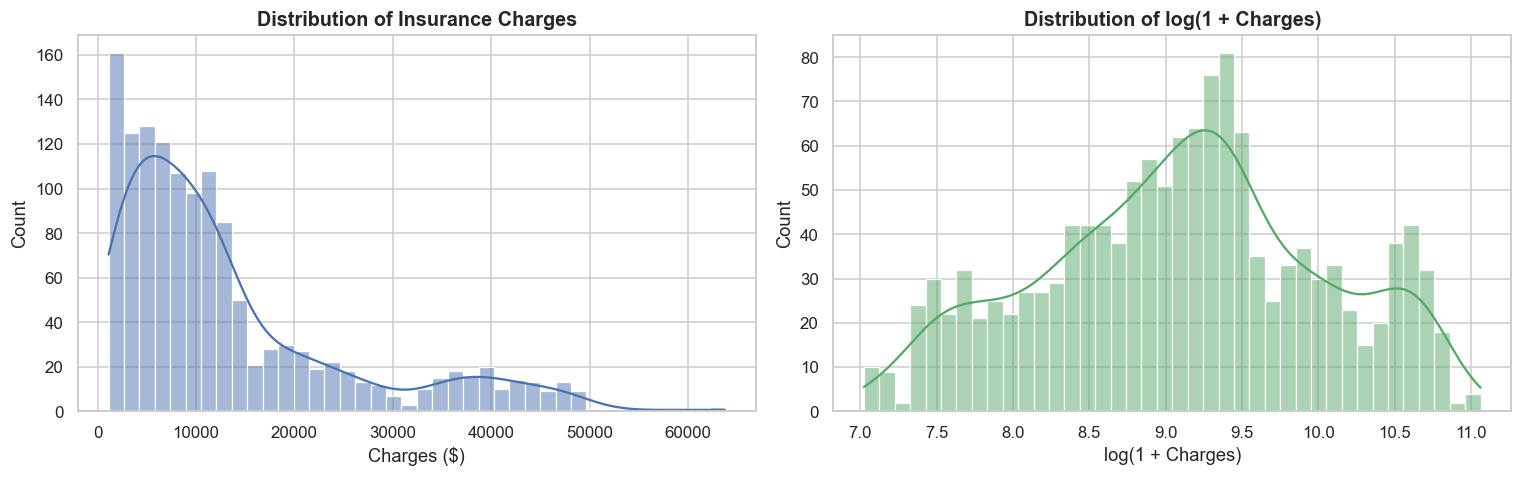

Charges skewness (raw):        1.52
Charges skewness (log-scaled): -0.09


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df["charges"], kde=True, bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Insurance Charges")
axes[0].set_xlabel("Charges ($)")
axes[0].set_ylabel("Count")

sns.histplot(np.log1p(df["charges"]), kde=True, bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of log(1 + Charges)")
axes[1].set_xlabel("log(1 + Charges)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Charges skewness (raw):        {df['charges'].skew():.2f}")
print(f"Charges skewness (log-scaled): {np.log1p(df['charges']).skew():.2f}")

`charges` is strongly **right-skewed** (skew ≈ 1.5) — meaning most people have
fairly low charges, but a long tail of a few very expensive patients pulls the
average up. A **log transform** (taking the logarithm of each value) squeezes
that long tail so the distribution looks more like a balanced bell curve. Linear
models tend to work better on balanced data, so we keep a log version of the
target as an alternative to try later.

Next, we turn from the target to the two continuous **predictors**, `age` and `bmi`.

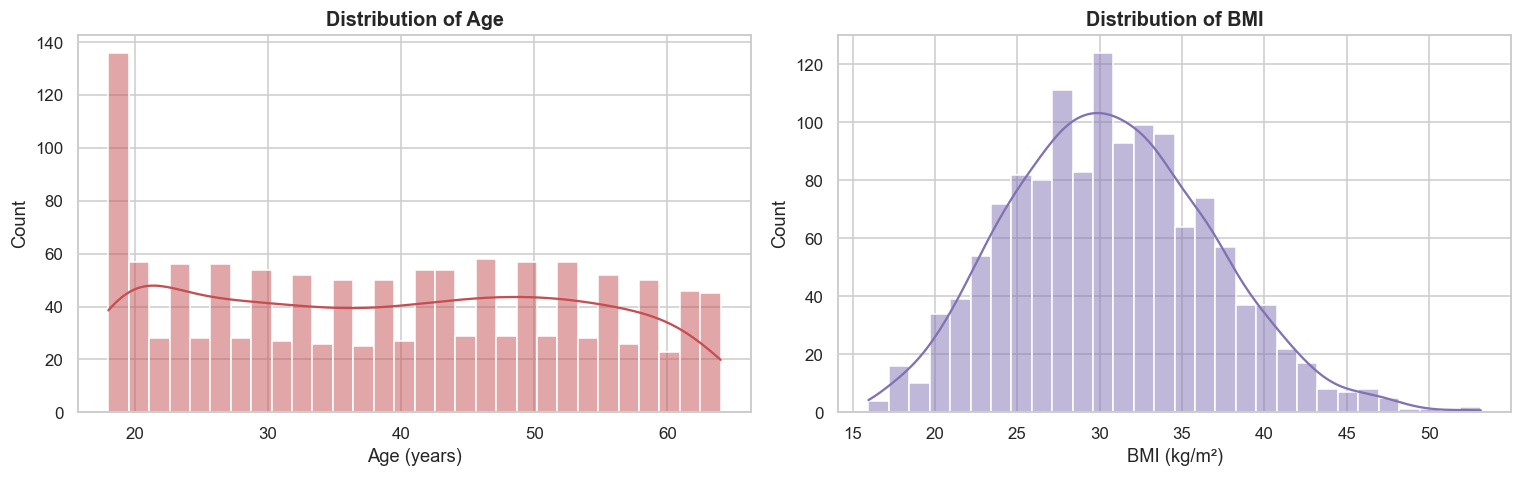

In [13]:
# Distributions of the continuous predictors
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["age"], kde=True, bins=30, ax=axes[0], color="#C44E52")
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age (years)")
sns.histplot(df["bmi"], kde=True, bins=30, ax=axes[1], color="#8172B3")
axes[1].set_title("Distribution of BMI")
axes[1].set_xlabel("BMI (kg/m²)")
plt.tight_layout()
plt.show()

Unlike `charges`, both predictors are fairly well behaved:

- **`age`** is spread roughly evenly across the full 18–64 range (with a small bump at the youngest ages), so no single age group dominates the sample.
- **`bmi`** is close to a symmetric bell shape centered near **30** — right at the clinical obesity threshold — with only a mild right tail.

Because neither predictor is badly skewed, they need no special transformation; simply putting them on a common scale before modeling will be enough.

### 6.2 Univariate — Categorical Variables

Count plots show how the sample is composed across `sex`, `smoker`, `region`,
and `children`.

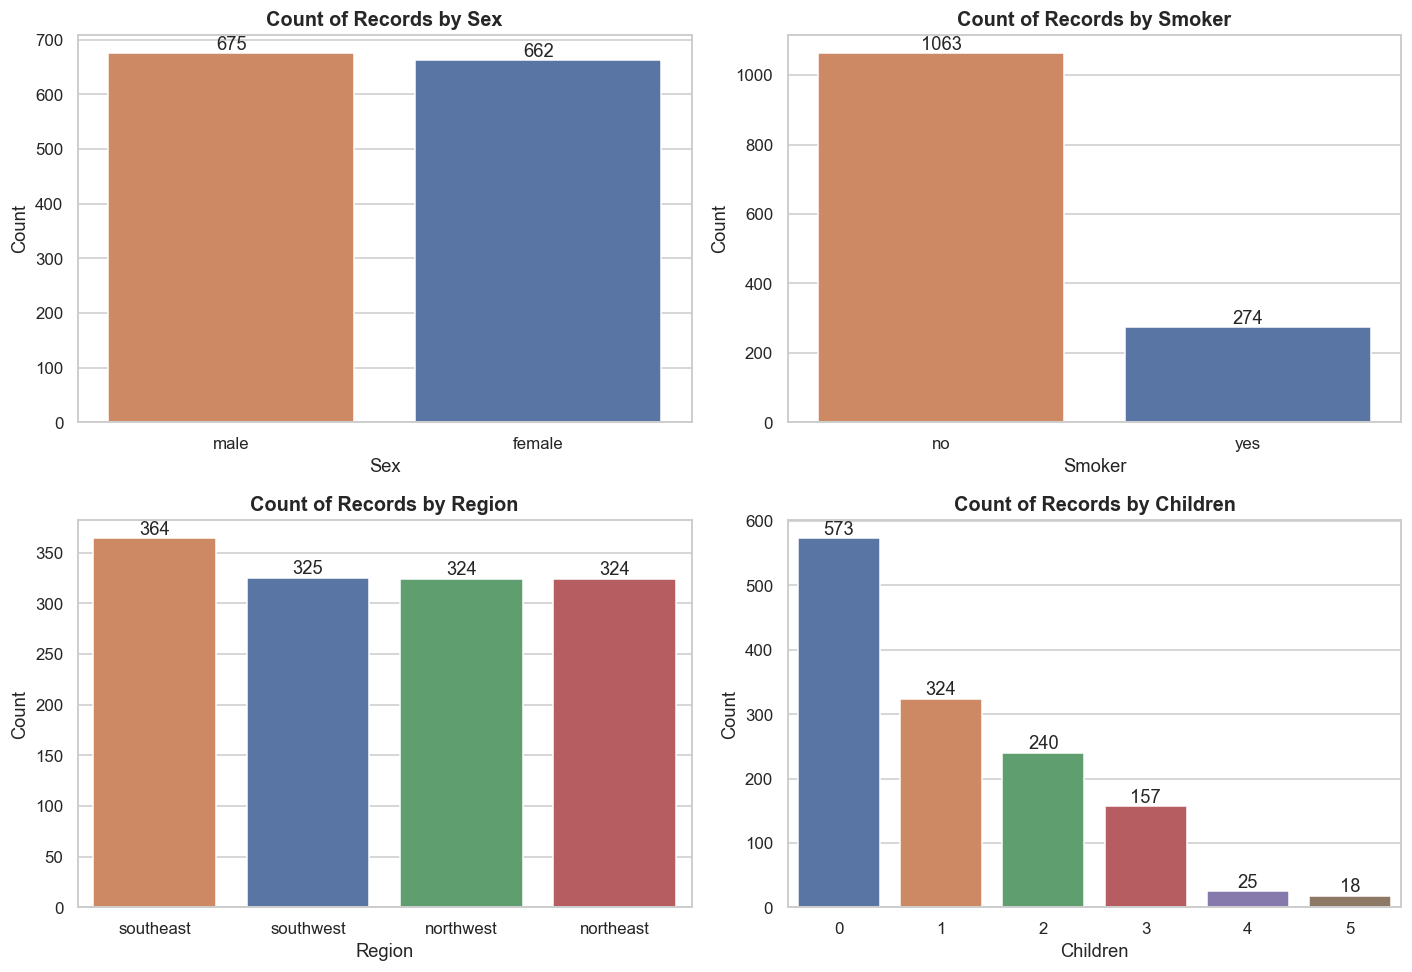

In [14]:
cat_cols = ["sex", "smoker", "region", "children"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, hue=col, legend=False, palette="deep")
    ax.set_title(f"Count of Records by {col.capitalize()}")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Count")
    for container in ax.containers:
        ax.bar_label(container)
plt.tight_layout()
plt.show()

**Observations:** the sample is roughly balanced by `sex` and across the four
`region`s. Crucially, **smokers are a minority (~20%)** — this class imbalance
matters because smoking turns out to be the dominant cost driver. Most
beneficiaries have 0–2 children.

### 6.3 Bivariate — What Drives Charges?

Now we examine how `charges` relates to each predictor. This is the heart of the
research question.

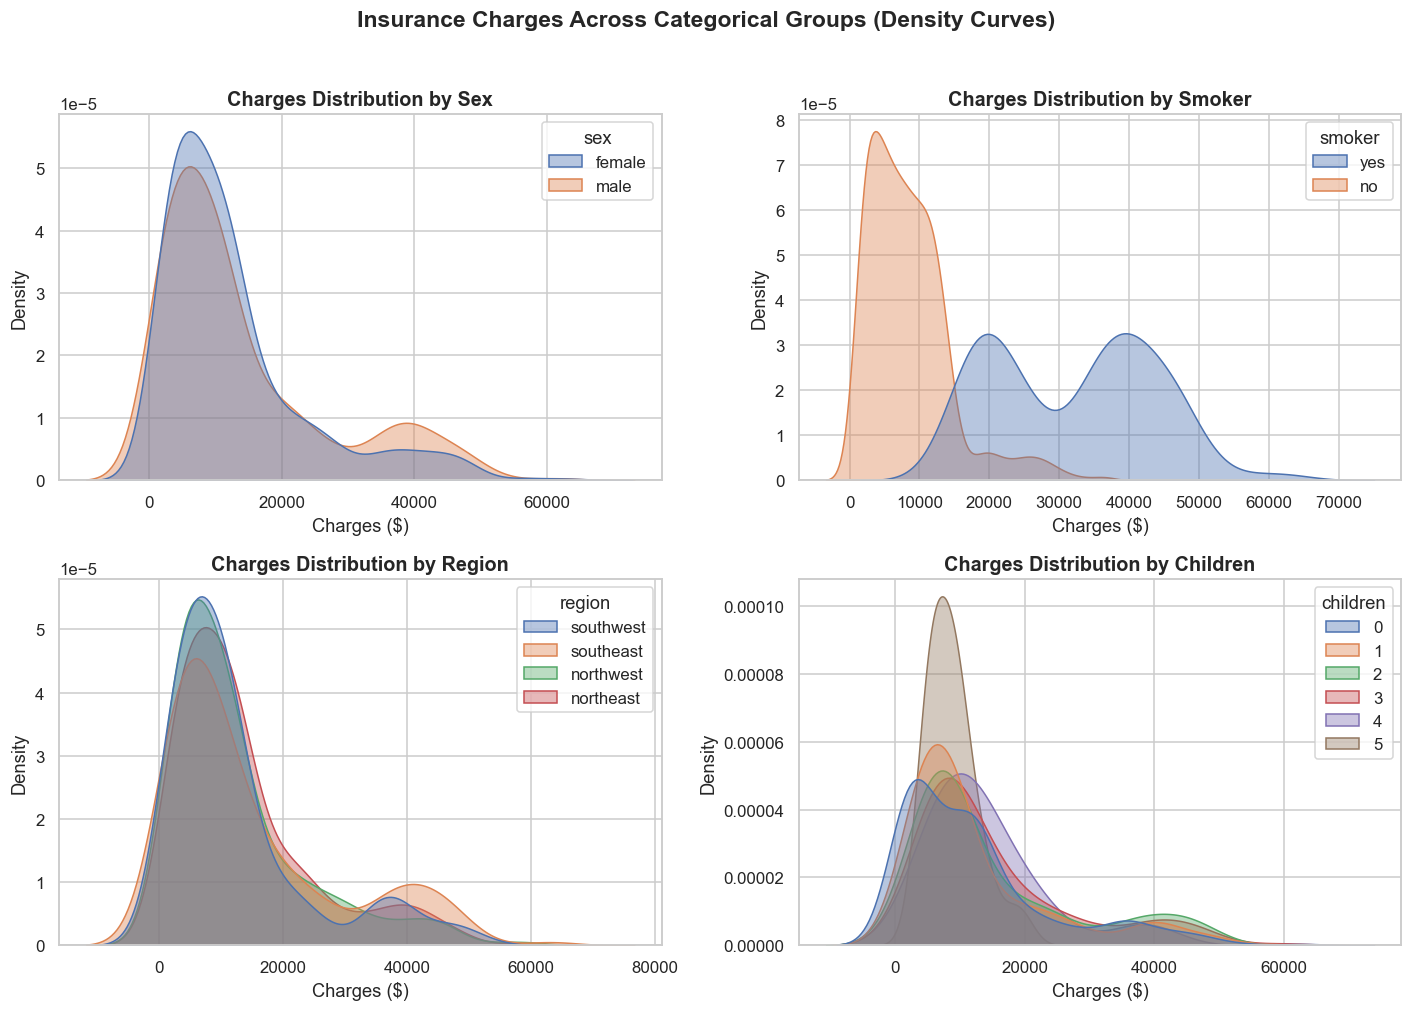

In [15]:
# Charges distribution within each categorical group (density curves)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.kdeplot(data=df, x="charges", hue=col, ax=ax, fill=True, alpha=0.4,
                common_norm=False, palette="deep")
    ax.set_title(f"Charges Distribution by {col.capitalize()}")
    ax.set_xlabel("Charges ($)")
    ax.set_ylabel("Density")
fig.suptitle("Insurance Charges Across Categorical Groups (Density Curves)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The `smoker` density curves are dramatic: the smoker and non-smoker charge
distributions barely overlap — **smokers are billed several times more**. By
contrast, the `sex`, `region`, and `children` curves sit almost on top of one
another — every group peaks in the same low-charge range — confirming these
factors have only a minor effect. In particular, the number of `children` shows
no clear ordering (families with more dependents are not billed systematically
more or less), which matches its very weak correlation with `charges` seen later.

In [16]:
# Quantify the smoker effect in dollar terms
smoker_stats = df.groupby("smoker")["charges"].agg(["mean", "median", "count"]).round(2)
smoker_stats["mean"] = smoker_stats["mean"].map("${:,.0f}".format)
smoker_stats["median"] = smoker_stats["median"].map("${:,.0f}".format)
print("Average charges by smoking status:")
smoker_stats

Average charges by smoking status:


,mean,median,count
smoker,,,
no,"$8,441","$7,346",1063
yes,"$32,050","$34,456",274


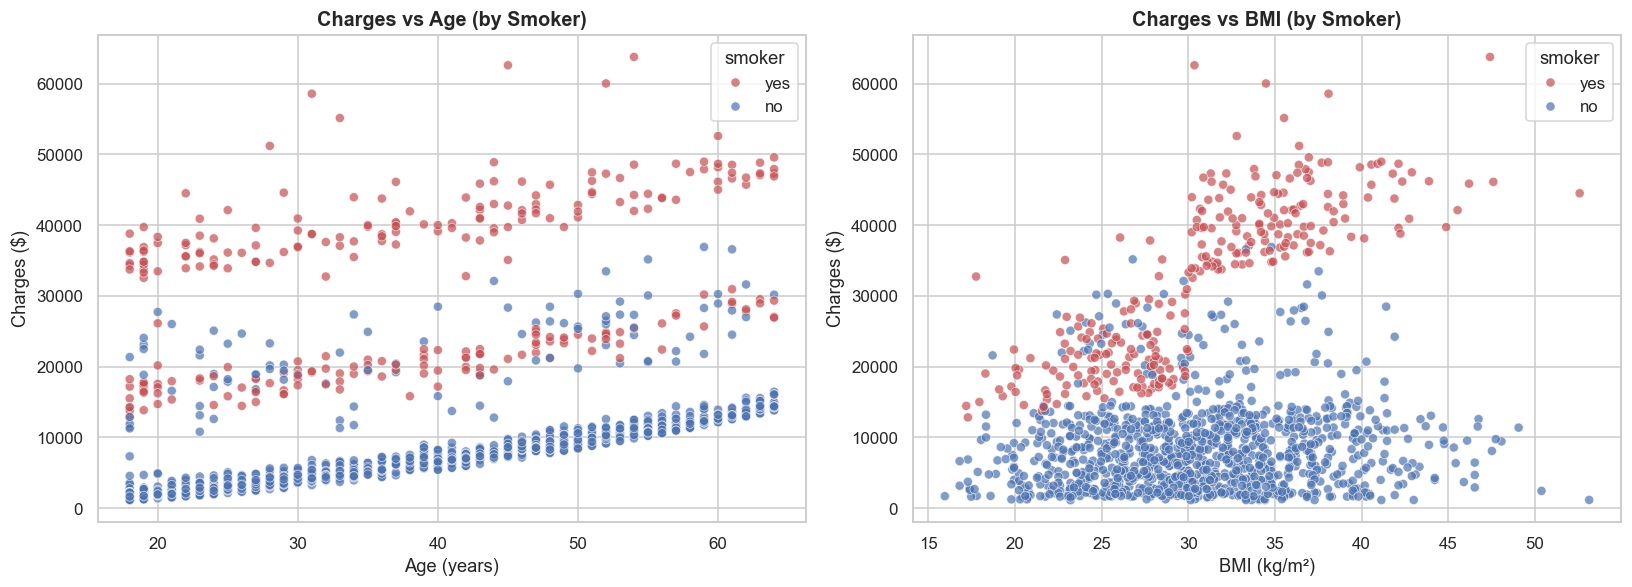

In [17]:
# Charges vs continuous variables, colored by smoker status
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7, ax=axes[0], palette={"yes": "#C44E52", "no": "#4C72B0"})
axes[0].set_title("Charges vs Age (by Smoker)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Charges ($)")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7, ax=axes[1], palette={"yes": "#C44E52", "no": "#4C72B0"})
axes[1].set_title("Charges vs BMI (by Smoker)")
axes[1].set_xlabel("BMI (kg/m²)")
axes[1].set_ylabel("Charges ($)")

plt.tight_layout()
plt.show()

These scatter plots reveal the **key structure** in the data:

- **Age vs Charges:** three roughly parallel bands. Charges rise steadily with
  age, but the whole smoker band sits far above the non-smoker band.
- **BMI vs Charges:** for **non-smokers**, BMI barely matters. For **smokers**,
  charges climb sharply once BMI crosses ~30 (the obesity threshold) — evidence
  of a **smoker × BMI interaction** we will engineer as a feature.

### 6.4 Correlation Analysis

We encode the binary categoricals and compute correlations with `charges`. A
pairwise heatmap summarizes linear relationships among numeric features.

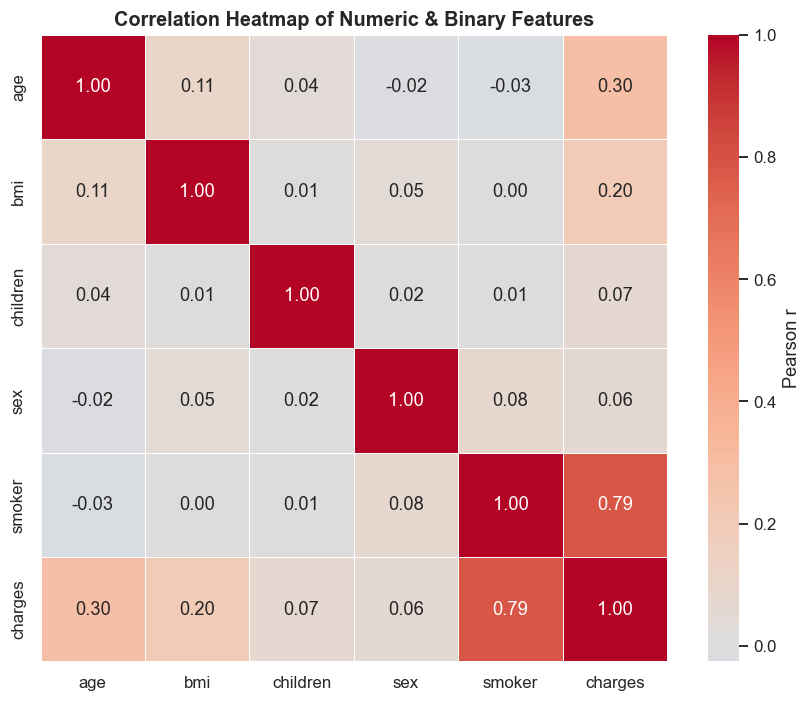

Correlation of each feature with charges:


smoker     0.79
age        0.30
bmi        0.20
children   0.07
sex        0.06
Name: charges, dtype: float64

In [18]:
# Numeric-encoded copy for correlation (binary vars -> 0/1)
corr_df = df.copy()
corr_df["sex"] = corr_df["sex"].map({"female": 0, "male": 1})
corr_df["smoker"] = corr_df["smoker"].map({"no": 0, "yes": 1})

corr = corr_df[["age", "bmi", "children", "sex", "smoker", "charges"]].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"})
plt.title("Correlation Heatmap of Numeric & Binary Features")
plt.tight_layout()
plt.show()

print("Correlation of each feature with charges:")
corr["charges"].drop("charges").sort_values(ascending=False)

`smoker` has by far the strongest linear correlation with `charges`
(r ≈ 0.79), followed by `age` and `bmi`. `sex` and `children` are weakly
correlated — consistent with our expectations.

## 7. Data Preparation — Feature Engineering

**Feature engineering** simply means reshaping the raw columns into a form the
model can use, and creating new columns that capture patterns we spotted during
EDA. Based on what we found, we make the following changes:

1. **Encode categoricals** — models only understand numbers, not words like
   "yes"/"no". So we convert them: `sex` and `smoker` become simple 0/1 columns,
   and `region` is **one-hot encoded** (each region gets its own 0/1 column).
2. **`bmi_category`** — group the raw BMI number into the standard WHO weight
   labels (underweight / normal / overweight / obese) so it's easier to read.
3. **`age_group`** — bucket ages into ranges (e.g. 18–29, 30–39, ...).
4. **`smoker_bmi` interaction** — a new column made by multiplying "is a smoker"
   by BMI. This lets the model learn the pattern we saw in the scatter plots:
   BMI drives up costs *much* more for smokers than for non-smokers.
5. **`log_charges`** — the log-transformed target from above, kept to try later
   as a way to handle the skew.

In [19]:
df_fe = df.copy()

# 7.1 Binary encoding
df_fe["sex_male"] = (df_fe["sex"] == "male").astype(int)
df_fe["smoker_yes"] = (df_fe["smoker"] == "yes").astype(int)

# 7.2 Clinical BMI categories (WHO)
def bmi_category(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 25:
        return "normal"
    elif bmi < 30:
        return "overweight"
    return "obese"

df_fe["bmi_category"] = df_fe["bmi"].apply(bmi_category)

# 7.3 Age groups
df_fe["age_group"] = pd.cut(df_fe["age"], bins=[17, 29, 39, 49, 64],
                            labels=["18-29", "30-39", "40-49", "50-64"])

# 7.4 Smoker x BMI interaction term
df_fe["smoker_bmi"] = df_fe["smoker_yes"] * df_fe["bmi"]

# 7.5 Log-transformed target
df_fe["log_charges"] = np.log1p(df_fe["charges"])

df_fe.head()

,age,sex,bmi,children,smoker,region,charges,sex_male,smoker_yes,bmi_category,age_group,smoker_bmi,log_charges
0,19,female,27.90,0,yes,southwest,"16,884.92",0,1,overweight,18-29,27.90,9.73
1,18,male,33.77,1,no,southeast,"1,725.55",1,0,obese,18-29,0.00,7.45
2,28,male,33.00,3,no,southeast,"4,449.46",1,0,obese,18-29,0.00,8.40
3,33,male,22.70,0,no,northwest,"21,984.47",1,0,normal,30-39,0.00,10.00
4,32,male,28.88,0,no,northwest,"3,866.86",1,0,overweight,30-39,0.00,8.26


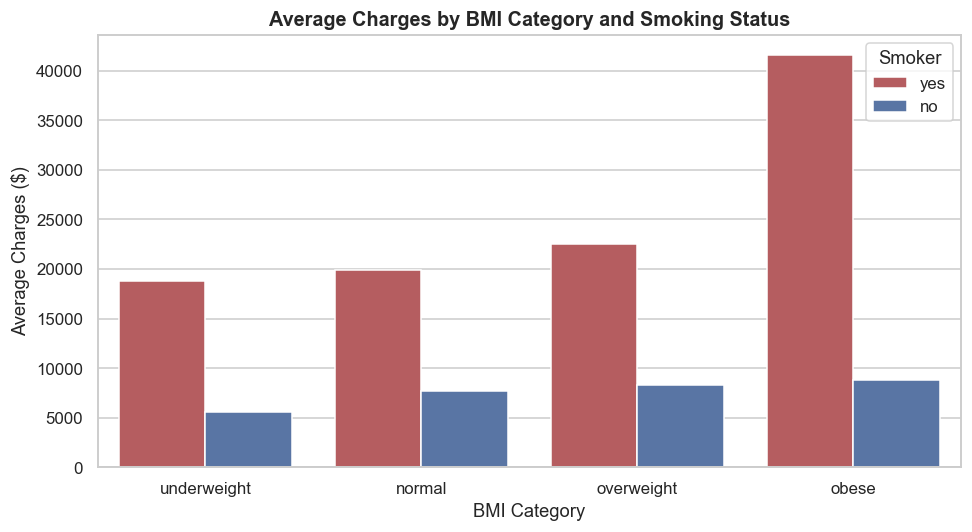

In [20]:
# Visualize an engineered feature: average charges by BMI category and smoker
plt.figure(figsize=(9, 5))
order = ["underweight", "normal", "overweight", "obese"]
sns.barplot(data=df_fe, x="bmi_category", y="charges", hue="smoker",
            order=order, palette={"yes": "#C44E52", "no": "#4C72B0"}, errorbar=None)
plt.title("Average Charges by BMI Category and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Average Charges ($)")
plt.legend(title="Smoker")
plt.tight_layout()
plt.show()

This engineered view confirms the interaction: among **non-smokers** charges
are flat across BMI categories, but among **smokers** average charges jump
substantially from overweight to obese — justifying the `smoker_bmi` feature.

## 8. Modeling — Baseline Linear Regression

We establish a **Linear Regression** baseline. It is the natural starting point
for a regression problem because it is **interpretable** — each coefficient
translates directly into "dollars per unit", which is exactly what the business
question asks for. This benchmark will be compared against more complex models
in the final capstone.

### 8.1 Feature/target setup and train/test split
We use the original raw features (`age`, `sex`, `bmi`, `children`, `smoker`,
`region`) plus the engineered `smoker_bmi` interaction, and hold out 20% of the
data for testing.

In [21]:
# Define features and target
feature_cols = ["age", "bmi", "children", "sex", "smoker", "region", "smoker_bmi"]
X = df_fe[feature_cols]
y = df_fe["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 1069 rows
Test set:     268 rows


### 8.2 Preprocessing + model pipeline

Before the model can learn, we prepare the columns in two ways:
- **Standardize** the number columns — put them on a common scale (so, e.g.,
  age in years and BMI aren't compared unfairly just because their raw sizes
  differ).
- **One-hot encode** the category columns — turn words into 0/1 columns.

We bundle these steps together with the model into a single **`Pipeline`**
(think of it as an assembly line: raw data goes in one end, a prediction comes
out the other). We fit this preprocessing using **only the training data**. This
avoids *data leakage* — accidentally letting the model peek at the test data
while learning — which would make our accuracy look better than it really is.

In [22]:
numeric_features = ["age", "bmi", "children", "smoker_bmi"]
categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features),
])

lin_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])

lin_model.fit(X_train, y_train)
print("Baseline Linear Regression trained.")

Baseline Linear Regression trained.


### 8.3 Evaluation

**Primary metric — Mean Absolute Error (MAE).** MAE reports the average error in
the *same units as the target (dollars)*, so it is directly interpretable for a
non-technical audience: "on average the prediction is off by $X." Unlike RMSE,
MAE does not over-penalize the naturally large errors on the high-cost smoker
tail, giving an honest picture of typical accuracy. We also report **RMSE** (to
surface large errors) and **R²** (share of variance explained) as supporting
context.

In [23]:
def evaluate(model, X_te, y_te, label):
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    print(f"--- {label} ---")
    print(f"MAE:  ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R^2:  {r2:.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

baseline_metrics = evaluate(lin_model, X_test, y_test, "Linear Regression (baseline)")

--- Linear Regression (baseline) ---
MAE:  $2,828.97
RMSE: $4,572.81
R^2:  0.886


**Baseline interpretation.** The two headline numbers answer different questions,
so we report both:

- **MAE ≈ \$2,830** says, in plain dollars, how far a typical prediction lands
  from the real bill. It is the *average of the absolute gaps* between the
  predicted and actual charge across the 268 held-out test people. For example,
  if the model predicts \$10,200 for someone who actually paid \$9,000, that is a
  \$1,200 miss; average every such miss and you get ≈ \$2,830. ("Absolute" means
  we count a miss the same whether the guess was too high or too low.)
- **R² ≈ 0.89** says the model captures about **89% of the person-to-person
  variation** in charges, leaving ~11% to random noise and factors not in the
  data.

These two don't contradict each other. Charges range from about \$1,100 to
\$64,000 (averaging ~\$13,000), so being off by only ~\$2.8k on values that vary
that widely is actually quite accurate — and that good *relative* accuracy is
exactly what produces the high R². For a first, fully interpretable baseline
this is strong, and it sets a concrete bar for the final capstone: a more complex
model is only worth the added complexity if it pushes MAE **below** \$2,830 or
R² **above** 0.89.

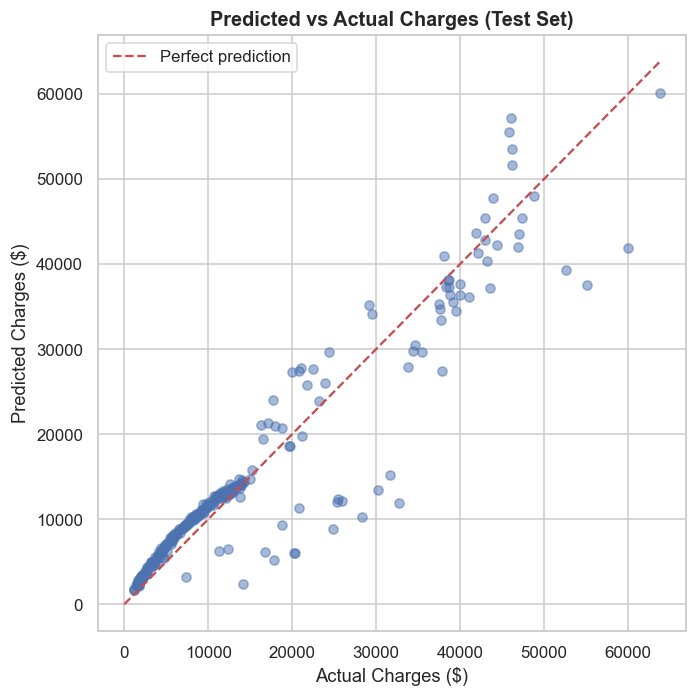

In [24]:
# Predicted vs actual charges on the test set
preds = lin_model.predict(X_test)
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, preds, alpha=0.5, color="#4C72B0")
lims = [0, max(y_test.max(), preds.max())]
plt.plot(lims, lims, "--", color="#C44E52", label="Perfect prediction")
plt.title("Predicted vs Actual Charges (Test Set)")
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.legend()
plt.tight_layout()
plt.show()

Most points cluster around the dashed "perfect prediction" line, so the model
tracks actual charges well across the bulk of the range. The scatter widens at
the top end — the model tends to under-predict a handful of the very highest-cost
patients — which is expected given how rare and variable those extreme bills are,
and it is exactly the behaviour the planned next-step models will try to improve.

### 8.4 Which factors drive charges? (Coefficient interpretation)

A **coefficient** is the "weight" the model gives each feature — how many dollars
the predicted charge moves when that feature goes up. Because we standardized the
number columns, their coefficients read as "dollars per one standard-deviation
step" (one typical-sized jump in that feature), while the category coefficients
read as "dollars compared to the left-out baseline group." So the size of each
bar tells us which factors push charges around the most. One caveat: the two
`smoker` bars must be read **together** (see the note below the chart).

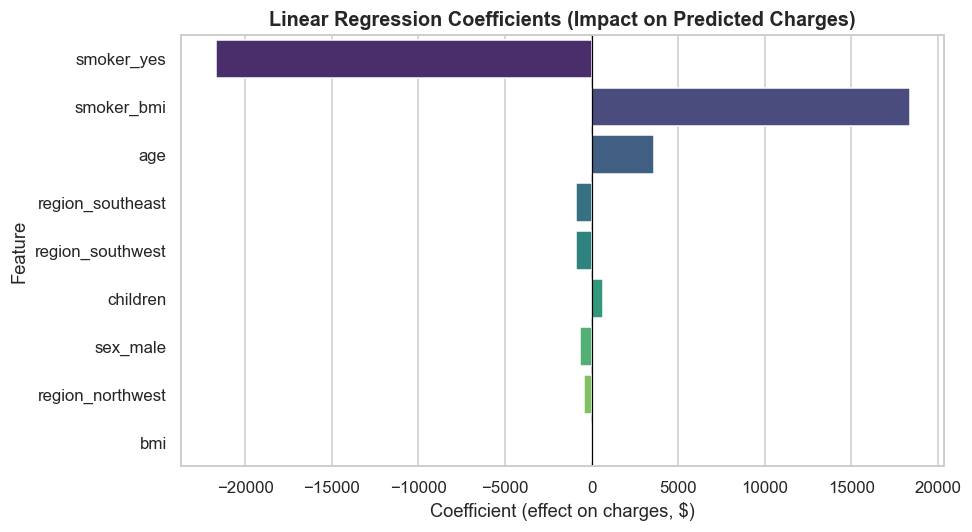

,feature,coefficient
0,smoker_yes,"-21,687.83"
1,smoker_bmi,"18,355.44"
2,age,"3,624.56"
3,region_southeast,-895.67
4,region_southwest,-884.56
5,children,680.72
6,sex_male,-647.37
7,region_northwest,-438.16
8,bmi,75.56


In [25]:
# Extract feature names and coefficients from the fitted pipeline
ohe = lin_model.named_steps["preprocess"].named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_names)

coefs = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": lin_model.named_steps["regressor"].coef_,
}).sort_values("coefficient", key=abs, ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=coefs, x="coefficient", y="feature", hue="feature", legend=False, palette="viridis")
plt.title("Linear Regression Coefficients (Impact on Predicted Charges)")
plt.xlabel("Coefficient (effect on charges, $)")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

coefs.reset_index(drop=True)

The coefficient ranking confirms the hypothesis: **smoking status is by far
the dominant driver** of charges, followed by **age**. **BMI** matters too, but
notice its standalone coefficient is tiny (≈ 76) — almost all of BMI's influence
flows through the `smoker_bmi` interaction, i.e. BMI mainly drives cost *for
smokers*. **Sex**, **children**, and **region** have comparatively small effects.

> **Reading the two smoker terms together.** The large *negative* `smoker_yes`
> bar does **not** mean smoking lowers costs. Because we added the `smoker × BMI`
> column, the model splits the smoker effect across two bars: `smoker_yes`
> (a starting adjustment) and `smoker_bmi` (extra dollars for every BMI point a
> smoker carries). You have to add them up. Once you do, the total for any real
> person's BMI is strongly *positive* — which matches the raw data, where
> smokers average **≈ \$32,050** vs **≈ \$8,441** for non-smokers (§6.3). In
> short, the interaction is what lets the model say "smoking is expensive, and
> it gets much more expensive as BMI rises," while non-smokers' costs barely move
> with BMI.

### 8.5 A simpler "which factors matter most?" view

The signed coefficients above are precise but a little awkward to read, because the
smoker effect is split across two bars. A more intuitive way to rank the drivers is
**permutation importance**: we shuffle one factor at a time and measure how much the
model's accuracy (MAE) gets *worse*. The bigger the drop, the more the model relies
on that factor — and every bar is positive, so there is nothing counterintuitive to
untangle. For a clean, one-bar-per-factor picture we use a simple main-effects model
(no interaction term); it confirms the exact same ranking.

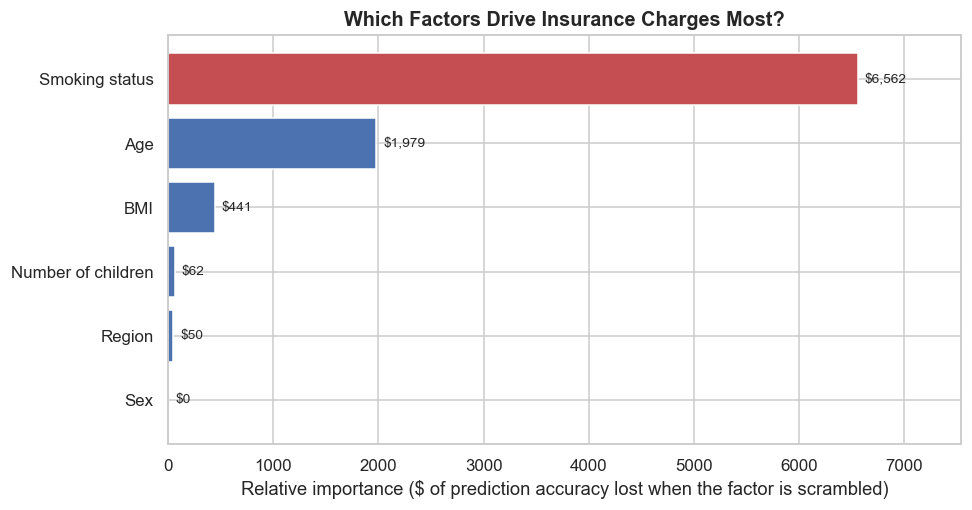

In [26]:
# Rank factors by permutation importance using a simple main-effects model
# (no interaction) so each original factor gets a single, easy-to-read bar.
rank_features = ["age", "bmi", "children", "sex", "smoker", "region"]
rank_preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), ["age", "bmi", "children"]),
    ("cat", OneHotEncoder(drop="first"), ["sex", "smoker", "region"]),
])
rank_model = Pipeline(steps=[
    ("preprocess", rank_preprocessor),
    ("regressor", LinearRegression()),
])
# Reuse the exact same train/test rows as the baseline model
rank_model.fit(df_fe[rank_features].loc[X_train.index], y_train)

perm = permutation_importance(
    rank_model, df_fe[rank_features].loc[X_test.index], y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error",
)

label_map = {"smoker": "Smoking status", "age": "Age", "bmi": "BMI",
             "children": "Number of children", "region": "Region", "sex": "Sex"}
importance = (pd.Series(perm.importances_mean, index=rank_features)
              .rename(index=label_map)
              .sort_values())

plt.figure(figsize=(9, 4.8))
bar_colors = ["#C44E52" if v == importance.max() else "#4C72B0" for v in importance.values]
plt.barh(importance.index, importance.values, color=bar_colors)
plt.title("Which Factors Drive Insurance Charges Most?")
plt.xlabel("Relative importance ($ of prediction accuracy lost when the factor is scrambled)")
for i, v in enumerate(importance.values):
    plt.text(v + importance.max() * 0.01, i, f"${v:,.0f}", va="center", fontsize=9)
plt.xlim(0, importance.max() * 1.15)
plt.tight_layout()
plt.show()

## 9. Evaluation — Summary of Findings

**Data quality.** The dataset is clean — no missing values, one exact duplicate
removed, all categories valid, correct data types.

**Outliers.** The apparent outliers in `charges` are legitimate high-cost
patients (mostly smokers / high BMI), not errors, so they were retained; the
right-skew was flagged and a log-transformed target prepared for later modeling.

**Key EDA insights:**
1. **Smoking is the dominant cost driver** — smokers are billed about
   **\$23,600 more** than non-smokers on average (\$32,050 vs \$8,441, ~4× higher).
2. **Age** raises charges steadily and roughly linearly.
3. **BMI** matters mainly *for smokers* — obese smokers incur dramatically
   higher costs (a clear interaction effect).
4. **Sex, children, and region** have only minor effects.

**Baseline model.** A Linear Regression pipeline (with a `smoker × BMI`
interaction) explains ~89% of the variance (R² ≈ 0.89) with an MAE of ≈ \$2,830.
MAE was chosen as the primary metric because it is expressed directly in dollars
and is robust to the heavy high-cost tail.

### Next steps (Module 24)
This baseline gives us a clear number to beat. Next, I'll try a few other
well-known prediction methods and see which one estimates charges most
accurately:
- **Simpler, self-tuning linear models** (for example, *Ridge* and *Lasso*
  regression) that automatically downplay the factors that don't add much, so
  the model stays lean and reliable.
- **Curved (non-straight-line) relationships** (for example, *polynomial
  regression*), to capture effects that speed up or slow down — like how costs
  accelerate at higher BMI for smokers.
- **"Grouping" and "look-alike" models** (for example, a *decision tree* or
  *k-nearest-neighbors*) that predict a person's cost by splitting the data into
  similar groups, or by comparing each person to others who look like them,
  instead of assuming a straight-line relationship.

I'll also:
- Re-test each model on several different splits of the data to make sure the
  results hold up and aren't just luck.
- Try predicting charges on a "smoothed" scale — for example, a **log
  transformation** of the charges — which tames the extreme values, then check
  whether it improves accuracy.
- Finish with the single best model plus a plain-English explanation of what
  drives costs — and by how many dollars — so a non-technical reader can act on
  it.
